In [1]:
import numpy as np

from Data_query.spark_config import *
from visualisation import *

spark.catalog.setCurrentDatabase("solar_analytics")
warehouse_dir = spark.conf.get("spark.sql.warehouse.dir")
print(warehouse_dir)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/16 05:45:19 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
25/09/16 05:45:22 WARN ConfigurationHelper: Option fs.s3a.connection.establish.timeout is too low (5,000 ms). Setting to 15,000 ms instead
Hive Session ID = 6fae648f-1fdf-4e61-901e-53277e88e977


s3a://project-ciccada/spark-warehouse


In [2]:
ts = spark.read.table("ts").filter(f"is_pv = True and year = 2024 and month = 1")
ts = ts.filter("circuit_id = 311097")
ts = ts.filter(f"t_stamp = '2024-01-18 00:00:00'")
ts.show()

+----------+-------------------+--------+--------+---------------+-------------+-------------+----------------------+----------------------+------------------+-------+-------+----+-----+-----+
|circuit_id|            t_stamp|   power|  energy|energy_reactive|energy_import|energy_export|energy_reactive_import|energy_reactive_export|      power_factor|voltage|current|year|month|is_pv|
+----------+-------------------+--------+--------+---------------+-------------+-------------+----------------------+----------------------+------------------+-------+-------+----+-----+-----+
|    311097|2024-01-18 00:00:00|10327.41|860.6175|       687.7775|     860.6175|          0.0|              687.7775|                   0.0|0.6102515078004142|  248.5| 54.968|2024|    1| true|
+----------+-------------------+--------+--------+---------------+-------------+-------------+----------------------+----------------------+------------------+-------+-------+----+-----+-----+



In [6]:
sites = spark.read.table("sites").filter("site_id = 1167741571").show()

+----------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+----------------+-------+------------------------+---------------------------+
|   site_id|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|    manufacturer|  model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|
+----------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+----------------+-------+------------------------+---------------------------+
|1167741571|  NSW|  2650.0|   147.35|   -35.1|Essential|         88.11|         77.43|           NULL|      2021-03-11|           1.0|     2021-03-12|Generic Inverter|77.43kW|                   77.43|                      false|
+----------+-----+--------+---------+--------+---------+--------------+-------------

In [9]:
spark.read.table("circuits").filter("circuit_id = 311097").show()

+----------+---------+----------+------------+----------------+------------+-----+
|   site_id|device_id|circuit_id| device_type|circuit_polarity|circuit_type|is_pv|
+----------+---------+----------+------------+----------------+------------+-----+
|1505360327|   130808|    311097|Watt Watcher|               1| pv_site_net| true|
+----------+---------+----------+------------+----------------+------------+-----+



In [2]:
import math


def get_voltvar_Q(V, Srated=1, v1=207, v2=220, v3=240, v4=258, Q1=0.44, Q4=0.60):
    if V <= v1:
        Q = Q1 * Srated
    elif v1 <= V < v2:
        m = (Q1 * Srated - 0) / (v1 - v2)
        Q = m * (V - v2)
    elif v2 <= V <= v3:
        Q = float(0)
    elif v3 < V < v4:
        m = (0 - Q4 * Srated) / (v3 - v4)
        Q = -m * (V - v4) - Q4 * Srated
    else:  # V >= v4
        Q = -Q4 * Srated

    return Q


def Q_capability_absorbing(P, Srated=1):
    if abs(P) < 0.2 * Srated:
        Q = float(0)
    elif abs(P) <= 0.6 * Srated:
        Q = -0.44 * Srated
    elif abs(P) <= 0.8 * Srated:
        S_pf = abs(P) / 0.8
        val = S_pf**2 - abs(P) ** 2
        if val < 0:  # protect against negatives
            Q = float(0)
        else:
            Q = -math.sqrt(val)
    else:
        val = Srated**2 - abs(P) ** 2
        if val < 0:  # protect against negatives
            Q = float(0)
        else:
            Q = -math.sqrt(val)
    return Q


get_voltvar_Q_udf = udf(get_voltvar_Q, DoubleType())
Q_capability_absorbing_udf = udf(Q_capability_absorbing, DoubleType())

In [3]:
def Q_impact(Q_kvar, Q_voltvar_max, Q_voltvar_min):
    if Q_kvar is None or Q_voltvar_max is None or Q_voltvar_min is None:
        return None

    def sign_val(x):
        return (x > 0) - (x < 0)

    eps = float(1e-9)
    r1 = abs(Q_kvar) / (abs(Q_voltvar_max) + eps)
    r2 = abs(Q_kvar) / (abs(Q_voltvar_min) + eps)

    if r1 <= r2:
        chosen = r1
        sign = sign_val(Q_voltvar_max) * sign_val(Q_kvar)
    else:
        chosen = r2
        sign = sign_val(Q_voltvar_min) * sign_val(Q_kvar)
    if Q_voltvar_max + Q_voltvar_min == 0:
        sign = 1
    return chosen * sign


Q_impact_udf = udf(Q_impact, DoubleType())

In [6]:
get_voltvar_Q(247.6, 110)

-27.866666666666646

In [27]:
# first_write = True
# for year in (2024, 2025):
# # for year in (2024, ):
#     # for month in (1, ):
#     for month in range(1, 13):
#         ts = spark.read.table("ts").filter(f"is_pv = True and year = {year} and month = {month}")\
#             .select("circuit_id", "t_stamp", "power", "energy_reactive", "voltage", "year", "month")
#         ts = ts.withColumn('voltage', when((col('voltage') > 300) | (col('voltage') < 0), None).otherwise(col('voltage')))
#         ts = ts.filter(col("voltage").isNotNull())
#         ts = ts.withColumn('P_kW', col('power') / 1000).drop('power')
#         ts = ts.withColumn('Q_kvar', col('energy_reactive') / 1000 * 12).drop('energy_reactive')

#         ts = ts.withColumn("day_night", expr("""
#                 CASE
#                     WHEN hour(from_utc_timestamp(t_stamp, 'UTC+10')) BETWEEN 9 AND 16
#                         THEN 'day'
#                     ELSE 'night'
#                 END
#             """))

#         meta = spark.read.table("meta_single_inverters_wrong_capacity_up2_3c").select("circuit_id","site_id", "ac_capacity_kw", 'circuit_polarity', 'wrong_capacity')\
#             .filter(col("wrong_capacity") == False).filter(col("ac_capacity_kw").isNotNull()).drop("wrong_capacity")\
#                 .withColumnRenamed("circuit_id", "circuit_id_meta")
#         df = ts.join(meta, ts.circuit_id == meta.circuit_id_meta, "inner").drop("circuit_id_meta")
#         df = df.withColumn('P_kW', col('P_kW') * col('circuit_polarity'))
#         df = df.withColumn('Q_kvar', col('Q_kvar') * col('circuit_polarity')).drop('circuit_polarity')
#         df = df.groupBy("site_id", "t_stamp", "year", "month", "day_night").agg(
#             spark_sum("P_kW").alias("P_kW"),
#             spark_sum("Q_kvar").alias("Q_kvar"),
#             avg("voltage").alias("voltage"),
#             avg("ac_capacity_kw").alias("ac_capacity_kw")
#         )
#         df = df.withColumn("Q_voltvar", get_voltvar_Q_udf(df.voltage, df.ac_capacity_kw))
#         df = df.withColumn("Q_voltvar_max", col("Q_voltvar").cast(DoubleType()) + .04*df.ac_capacity_kw)
#         df = df.withColumn("Q_voltvar_min", col("Q_voltvar").cast(DoubleType()) - .04*df.ac_capacity_kw)
#         df = df.withColumn("Q_capability_absorbing", Q_capability_absorbing_udf(df.P_kW, df.ac_capacity_kw))
#         df = df.withColumn("Q_capability_supplying", col("Q_capability_absorbing") * -1)

#         df = df.withColumn("Q_voltvar_max", when(col("Q_voltvar_max") < lit(0), \
#                                                  greatest(col("Q_voltvar_max"), col("Q_capability_absorbing")+ .04*df.ac_capacity_kw))\
#                         .otherwise(col("Q_voltvar_max")))


#         df = df.withColumn("Q_voltvar_min", when(col("Q_voltvar_min") > lit(0), \
#                                                  least(col("Q_voltvar_min"), col("Q_capability_supplying")- .04*df.ac_capacity_kw))\
#                         .otherwise(col("Q_voltvar_min")))

#         df = df.withColumn("extra_absorb", when((col("Q_kvar") < 0) & (col("Q_kvar") < col("Q_voltvar_min")), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("deficit_absorb", when((col("Q_kvar") < 0) & (col("Q_kvar") > col("Q_voltvar_max")), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("extra_supply", when((col("Q_kvar") > 0) & (col("Q_kvar") > col("Q_voltvar_max")), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("deficit_supply", when((col("Q_kvar") > 0) & (col("Q_kvar") < col("Q_voltvar_min")), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("noncompliance_voltvar", col("extra_absorb") + col("deficit_absorb")+ col("extra_supply")+ col("deficit_supply"))

#         df = df.withColumn("day", dayofmonth(col("t_stamp")))
#         comp = df.groupBy('year','month',"day", "site_id", "day_night")\
#             .agg(spark_sum(when(col("noncompliance_voltvar") > 0, 1).otherwise(0)).alias("noncompliance_voltvar_count"), \
#             spark_sum(col("noncompliance_voltvar")).alias("noncompliance_voltvar_sum"),
#                 spark_sum(col("extra_absorb")).alias("Q_extra_absorb"),
#                 spark_sum(col("extra_supply")).alias("Q_extra_supply"),
#                 spark_sum(col("deficit_supply")).alias("Q_deficit_supply"),
#                 spark_sum(col("deficit_absorb")).alias("Q_deficit_absorb"),
#                 spark_count(col("noncompliance_voltvar")).alias("total_count")
#             )\
#             # .sort("noncompliance_voltvar_count", ascending=False)
#         if first_write:
#             comp.write.mode("overwrite").parquet(f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet")
#             first_write = False
#         else:
#             comp.write.mode("append").parquet(f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet")

In [34]:
month

2

In [ ]:
# first_write = True
# for year in (2024, 2025):
# # for year in (2025, ):
#     # for month in (1, ):
#     for month in range(1, 13):
#         ts = spark.read.table("ts").filter(f"is_pv = True and year = {year} and month = {month}")\
#             .select("circuit_id", "t_stamp", "power", "energy_reactive", "voltage", "year", "month")
#         ts = ts.withColumn('voltage', when((col('voltage') > 300) | (col('voltage') < 0), None).otherwise(col('voltage')))
#         ts = ts.filter(col("voltage").isNotNull())
#         ts = ts.withColumn('P_kW', col('power') / 1000).drop('power')
#         ts = ts.withColumn('Q_kvar', col('energy_reactive') / 1000 * 12).drop('energy_reactive')

#         ts = ts.withColumn("day_night", expr("""
#                 CASE
#                     WHEN hour(from_utc_timestamp(t_stamp, 'UTC+10')) BETWEEN 9 AND 16
#                         THEN 'day'
#                     ELSE 'night'
#                 END
#             """))

#         meta = spark.read.table("meta_single_inverters_wrong_capacity_up2_3c").select("circuit_id","site_id", "s_id","ac_capacity_kw", 'circuit_polarity', 'wrong_capacity')\
#             .filter(col("wrong_capacity") == False).filter(col("ac_capacity_kw").isNotNull()).drop("wrong_capacity")\
#                 .withColumnRenamed("circuit_id", "circuit_id_meta")
#         df = ts.join(meta, ts.circuit_id == meta.circuit_id_meta, "inner").drop("circuit_id_meta")
#         df = df.withColumn('P_kW', col('P_kW') * col('circuit_polarity'))
#         df = df.withColumn('Q_kvar', col('Q_kvar') * col('circuit_polarity')).drop('circuit_polarity')
#         df = df.groupBy("site_id", "s_id","t_stamp", "year", "month", "day_night").agg(
#             spark_sum("P_kW").alias("P_kW"),
#             spark_sum("Q_kvar").alias("Q_kvar"),
#             avg("voltage").alias("voltage"),
#             avg("ac_capacity_kw").alias("ac_capacity_kw")
#         )
#         df = df.withColumn("PF", col("P_kW") / (col("P_kW")**2 + col("Q_kvar")**2)**0.5)
#         df = df.withColumn("Q_voltvar", get_voltvar_Q_udf(df.voltage, df.ac_capacity_kw))
#         df = df.withColumn("Q_voltvar_max", col("Q_voltvar").cast(DoubleType()) + .04*df.ac_capacity_kw)
#         df = df.withColumn("Q_voltvar_min", col("Q_voltvar").cast(DoubleType()) - .04*df.ac_capacity_kw)
#         df = df.withColumn("Q_capability_absorbing", Q_capability_absorbing_udf(df.P_kW, df.ac_capacity_kw))
#         df = df.withColumn("Q_capability_supplying", col("Q_capability_absorbing") * -1)

#         df = df.withColumn("Q_voltvar_max", when(col("Q_voltvar_max") < lit(0), \
#                                                  greatest(col("Q_voltvar_max"), col("Q_capability_absorbing")+ .04*df.ac_capacity_kw))\
#                         .otherwise(col("Q_voltvar_max")))


#         df = df.withColumn("Q_voltvar_min", when(col("Q_voltvar_min") > lit(0), \
#                                                  least(col("Q_voltvar_min"), col("Q_capability_supplying")- .04*df.ac_capacity_kw))\
#                         .otherwise(col("Q_voltvar_min")))

#         df = df.withColumn("Q_impact", Q_impact_udf(df.Q_kvar, df.Q_voltvar_max, df.Q_voltvar_min))

#         neg_threshold = -0.5
#         pos_threshold = 1.25
#         df = df.withColumn("extra_absorb_adv_high", when((col("Q_kvar") < 0) & (col("Q_kvar") < col("Q_voltvar_min")) \
#                                                                             & (col("Q_impact") < neg_threshold), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))
#         df = df.withColumn("extra_absorb_adv_low", when((col("Q_kvar") < 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") >= neg_threshold) & (col("Q_impact") < 0), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))
#         df = df.withColumn("extra_absorb_ben_low", when((col("Q_kvar") < 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") >= 0) & (col("Q_impact") < pos_threshold), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))
#         df = df.withColumn("extra_absorb_ben_high", when((col("Q_kvar") < 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") >= pos_threshold), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("deficit_absorb_adv_high", when((col("Q_kvar") < 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") < neg_threshold), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("deficit_absorb_adv_low", when((col("Q_kvar") < 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") >= neg_threshold) & (col("Q_impact") < 0), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("deficit_absorb_ben_low", when((col("Q_kvar") < 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") >= 0) & (col("Q_impact") < pos_threshold), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("deficit_absorb_ben_high", when((col("Q_kvar") < 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") >= pos_threshold), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("extra_supply_adv_high", when((col("Q_kvar") > 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") < neg_threshold), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("extra_supply_adv_low", when((col("Q_kvar") > 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") >= neg_threshold) & (col("Q_impact") < 0), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("extra_supply_ben_low", when((col("Q_kvar") > 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") >= 0) & (col("Q_impact") < pos_threshold), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("extra_supply_ben_high", when((col("Q_kvar") > 0) & (col("Q_kvar") > col("Q_voltvar_max"))\
#                                                                             & (col("Q_impact") >= pos_threshold), \
#                                                 col("Q_kvar") - col("Q_voltvar_max")).otherwise(lit(0)))

#         df = df.withColumn("deficit_supply_adv_high", when((col("Q_kvar") > 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") < neg_threshold), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("deficit_supply_adv_low", when((col("Q_kvar") > 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") >= neg_threshold) & (col("Q_impact") < 0), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("deficit_supply_ben_low", when((col("Q_kvar") > 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") >= 0) & (col("Q_impact") < pos_threshold), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("deficit_supply_ben_high", when((col("Q_kvar") > 0) & (col("Q_kvar") < col("Q_voltvar_min"))\
#                                                                             & (col("Q_impact") >= pos_threshold), \
#                                                 col("Q_voltvar_min") - col("Q_kvar")).otherwise(lit(0)))

#         df = df.withColumn("noncompliance_voltvar", \
#                     col("extra_absorb_adv_high") + col("extra_absorb_adv_low") +col("extra_absorb_ben_high") +col("extra_absorb_ben_low") +\
#                     col("deficit_absorb_adv_high")+ col("deficit_absorb_adv_low")+ col("deficit_absorb_ben_high")+ col("deficit_absorb_ben_low")+ \
#                     col("extra_supply_adv_high")+ col("extra_supply_adv_low")+ col("extra_supply_ben_high")+ col("extra_supply_ben_low")+ \
#                     col("deficit_supply_adv_high")+col("deficit_supply_adv_low")+col("deficit_supply_ben_high")+col("deficit_supply_ben_low"))

#         df = df.withColumn("day", dayofmonth(col("t_stamp")))
#         comp = df.groupBy('year','month',"day", "site_id", "s_id", "day_night")\
#             .agg(spark_sum(when(col("noncompliance_voltvar") > 0, 1).otherwise(0)).alias("noncompliance_voltvar_count"), \
#             spark_sum(col("noncompliance_voltvar")).alias("noncompliance_voltvar_sum"),
#                 spark_sum(col("extra_absorb_adv_high")).alias("Q_extra_absorb_adv_high"),
#                 spark_sum(col("extra_absorb_adv_low")).alias("Q_extra_absorb_adv_low"),
#                 spark_sum(col("extra_absorb_ben_high")).alias("Q_extra_absorb_ben_high"),
#                 spark_sum(col("extra_absorb_ben_low")).alias("Q_extra_absorb_ben_low"),
#                 spark_sum(col("extra_supply_adv_high")).alias("Q_extra_supply_adv_high"),
#                 spark_sum(col("extra_supply_adv_low")).alias("Q_extra_supply_adv_low"),
#                 spark_sum(col("extra_supply_ben_high")).alias("Q_extra_supply_ben_high"),
#                 spark_sum(col("extra_supply_ben_low")).alias("Q_extra_supply_ben_low"),
#                 spark_sum(col("deficit_supply_adv_high")).alias("Q_deficit_supply_adv_high"),
#                 spark_sum(col("deficit_supply_adv_low")).alias("Q_deficit_supply_adv_low"),
#                 spark_sum(col("deficit_supply_ben_high")).alias("Q_deficit_supply_ben_high"),
#                 spark_sum(col("deficit_supply_ben_low")).alias("Q_deficit_supply_ben_low"),
#                 spark_sum(col("deficit_absorb_adv_high")).alias("Q_deficit_absorb_adv_high"),
#                 spark_sum(col("deficit_absorb_adv_low")).alias("Q_deficit_absorb_adv_low"),
#                 spark_sum(col("deficit_absorb_ben_high")).alias("Q_deficit_absorb_ben_high"),
#                 spark_sum(col("deficit_absorb_ben_low")).alias("Q_deficit_absorb_ben_low"),
#                 spark_count(col("noncompliance_voltvar")).alias("total_count"),
#                 spark_sum(when(col("extra_absorb_adv_high") > 0, 1).otherwise(0)).alias("Q_extra_absorb_adv_high_count"), \
#                 spark_sum(when(col("extra_absorb_adv_low") > 0, 1).otherwise(0)).alias("Q_extra_absorb_adv_low_count"), \
#                 spark_sum(when(col("extra_absorb_ben_high") > 0, 1).otherwise(0)).alias("Q_extra_absorb_ben_high_count"), \
#                 spark_sum(when(col("extra_absorb_ben_low") > 0, 1).otherwise(0)).alias("Q_extra_absorb_ben_low_count"), \
#                 spark_sum(when(col("deficit_absorb_adv_high") > 0, 1).otherwise(0)).alias("Q_deficit_absorb_adv_high_count"), \
#                 spark_sum(when(col("deficit_absorb_adv_low") > 0, 1).otherwise(0)).alias("Q_deficit_absorb_adv_low_count"), \
#                 spark_sum(when(col("deficit_absorb_ben_high") > 0, 1).otherwise(0)).alias("Q_deficit_absorb_ben_high_count"), \
#                 spark_sum(when(col("deficit_absorb_ben_low") > 0, 1).otherwise(0)).alias("Q_deficit_absorb_ben_low_count"), \
#                 spark_sum(when(col("extra_supply_adv_high") > 0, 1).otherwise(0)).alias("Q_extra_supply_adv_high_count"), \
#                 spark_sum(when(col("extra_supply_adv_low") > 0, 1).otherwise(0)).alias("Q_extra_supply_adv_low_count"), \
#                 spark_sum(when(col("extra_supply_ben_high") > 0, 1).otherwise(0)).alias("Q_extra_supply_ben_high_count"), \
#                 spark_sum(when(col("extra_supply_ben_low") > 0, 1).otherwise(0)).alias("Q_extra_supply_ben_low_count"), \
#                 spark_sum(when(col("deficit_supply_adv_high") > 0, 1).otherwise(0)).alias("Q_deficit_supply_adv_high_count"), \
#                 spark_sum(when(col("deficit_supply_adv_low") > 0, 1).otherwise(0)).alias("Q_deficit_supply_adv_low_count"), \
#                 spark_sum(when(col("deficit_supply_ben_high") > 0, 1).otherwise(0)).alias("Q_deficit_supply_ben_high_count"), \
#                 spark_sum(when(col("deficit_supply_ben_low") > 0,   1).otherwise(0)).alias("Q_deficit_supply_ben_low_count")
#             )\
#             # .sort("noncompliance_voltvar_count", ascending=False)
#         if first_write:
#             comp.write.mode("overwrite").parquet(f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet")
#             first_write = False
#         else:
#             comp.write.mode("append").parquet(f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet")

25/09/10 11:00:33 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/09/10 11:05:49 WARN S3ABlockOutputStream: Application invoked the Syncable API against stream writing to spark-warehouse/Compliance_results_SolA/compliance_voltvar.parquet/_temporary/0/_temporary/attempt_202509101105457638205501979836707_0006_m_000000_109/part-00000-ba429025-86f8-41a1-9be5-83137f838cc5-c000.snappy.parquet. This is Unsupported


In [ ]:
first_write = True
for year in (2024, 2025):
    # for year in (2025, ):
    # for month in (1, ):
    for month in range(1, 13):
        ts = (
            spark.read.table("ts")
            .filter(f"is_pv = True and year = {year} and month = {month}")
            .select(
                "circuit_id",
                "t_stamp",
                "power",
                "energy_reactive",
                "voltage",
                "year",
                "month",
            )
        )

        ts = ts.withColumn("P_kW", col("power") / 1000).drop("power")
        ts = ts.withColumn("Q_kvar", col("energy_reactive") / 1000 * 12).drop(
            "energy_reactive"
        )

        ts = ts.withColumn(
            "day_night",
            expr("""
                CASE 
                    WHEN hour(from_utc_timestamp(t_stamp, 'UTC+10')) BETWEEN 8 AND 16 
                        THEN 'day'
                    ELSE 'night'
                END
            """),
        )

        meta = (
            spark.read.table("meta_single_inverters_wrong_capacity_up2_3c")
            .select(
                "circuit_id",
                "site_id",
                "s_id",
                "ac_capacity_kw",
                "circuit_polarity",
                "wrong_capacity",
            )
            .filter(col("wrong_capacity") == False)
            .filter(col("ac_capacity_kw").isNotNull())
            .drop("wrong_capacity")
            .withColumnRenamed("circuit_id", "circuit_id_meta")
        )
        df = ts.join(meta, ts.circuit_id == meta.circuit_id_meta, "inner").drop(
            "circuit_id_meta"
        )
        df = df.withColumn("P_kW", col("P_kW") * col("circuit_polarity"))
        df = df.withColumn("Q_kvar", col("Q_kvar") * col("circuit_polarity")).drop(
            "circuit_polarity"
        )
        df = df.groupBy("site_id", "s_id", "t_stamp", "year", "month", "day_night").agg(
            spark_sum("P_kW").alias("P_kW"),
            spark_sum("Q_kvar").alias("Q_kvar"),
            avg("voltage").alias("voltage"),
            avg("ac_capacity_kw").alias("ac_capacity_kw"),
        )
        df = df.withColumn(
            "voltage",
            when((col("voltage") > 300) | (col("voltage") < 0), None).otherwise(
                col("voltage")
            ),
        )
        df = df.filter(col("voltage").isNotNull())
        df = df.withColumn(
            "PF", col("P_kW") / (col("P_kW") ** 2 + col("Q_kvar") ** 2) ** 0.5
        )
        df = df.withColumn(
            "Q_voltvar", get_voltvar_Q_udf(df.voltage, df.ac_capacity_kw)
        )
        df = df.withColumn(
            "Q_voltvar_max",
            col("Q_voltvar").cast(DoubleType()) + 0.04 * df.ac_capacity_kw,
        )
        df = df.withColumn(
            "Q_voltvar_min",
            col("Q_voltvar").cast(DoubleType()) - 0.04 * df.ac_capacity_kw,
        )
        df = df.withColumn(
            "Q_capability_absorbing",
            Q_capability_absorbing_udf(df.P_kW, df.ac_capacity_kw),
        )
        df = df.withColumn("Q_capability_supplying", col("Q_capability_absorbing") * -1)

        df = df.withColumn(
            "Q_voltvar_max",
            when(
                col("Q_voltvar_max") < lit(0),
                greatest(
                    col("Q_voltvar_max"),
                    col("Q_capability_absorbing") + 0.04 * df.ac_capacity_kw,
                ),
            ).otherwise(col("Q_voltvar_max")),
        )

        df = df.withColumn(
            "Q_voltvar_min",
            when(
                col("Q_voltvar_min") > lit(0),
                least(
                    col("Q_voltvar_min"),
                    col("Q_capability_supplying") - 0.04 * df.ac_capacity_kw,
                ),
            ).otherwise(col("Q_voltvar_min")),
        )

        df = df.withColumn(
            "Q_impact", Q_impact_udf(df.Q_kvar, df.Q_voltvar_max, df.Q_voltvar_min)
        )

        thr1 = -0.1
        thr2 = 0.1
        thr3 = 0.9
        thr4 = 1.1
        outside_bounds = (col("Q_kvar") < col("Q_voltvar_min")) | (
            col("Q_kvar") > col("Q_voltvar_max")
        )
        noncompliance_value = least(
            spark_abs(col("Q_kvar") - col("Q_voltvar_min")),
            spark_abs(col("Q_kvar") - col("Q_voltvar_max")),
        )

        df = df.withColumn(
            "Q_adverse",
            when(
                outside_bounds & (col("Q_impact") < thr1), noncompliance_value
            ).otherwise(lit(0)),
        )

        df = df.withColumn(
            "Q_inactive",
            when(
                outside_bounds & (col("Q_impact") >= thr1) & (col("Q_impact") <= thr2),
                noncompliance_value,
            ).otherwise(lit(0)),
        )

        df = df.withColumn(
            "Q_minor",
            when(
                outside_bounds & (col("Q_impact") > thr2) & (col("Q_impact") < thr3),
                noncompliance_value,
            ).otherwise(lit(0)),
        )

        df = df.withColumn(
            "Q_major",
            when(
                outside_bounds & (col("Q_impact") >= thr3) & (col("Q_impact") <= thr4),
                noncompliance_value,
            ).otherwise(lit(0)),
        )

        df = df.withColumn(
            "Q_benevolent",
            when(
                outside_bounds & (col("Q_impact") > thr4), noncompliance_value
            ).otherwise(lit(0)),
        )

        df = df.withColumn(
            "noncompliance_voltvar",
            col("Q_adverse")
            + col("Q_inactive")
            + col("Q_minor")
            + col("Q_major")
            + col("Q_benevolent"),
        )

        df = df.withColumn("day", dayofmonth(col("t_stamp")))
        comp = df.groupBy("year", "month", "day", "site_id", "s_id", "day_night").agg(
            spark_sum(when(col("noncompliance_voltvar") > 0, 1).otherwise(0)).alias(
                "noncompliance_voltvar_count"
            ),
            spark_sum(col("noncompliance_voltvar")).alias("noncompliance_voltvar_sum"),
            spark_sum(col("Q_adverse")).alias("Q_adverse"),
            spark_sum(col("Q_inactive")).alias("Q_inactive"),
            spark_sum(col("Q_minor")).alias("Q_minor"),
            spark_sum(col("Q_major")).alias("Q_major"),
            spark_sum(col("Q_benevolent")).alias("Q_benevolent"),
            spark_count(col("noncompliance_voltvar")).alias("total_count"),
            spark_sum(when(col("Q_adverse") > 0, 1).otherwise(0)).alias(
                "Q_adverse_count"
            ),
            spark_sum(when(col("Q_inactive") > 0, 1).otherwise(0)).alias(
                "Q_inactive_count"
            ),
            spark_sum(when(col("Q_minor") > 0, 1).otherwise(0)).alias("Q_minor_count"),
            spark_sum(when(col("Q_major") > 0, 1).otherwise(0)).alias("Q_major_count"),
            spark_sum(when(col("Q_benevolent") > 0, 1).otherwise(0)).alias(
                "Q_benevolent_count"
            ),
        )
        # .sort("noncompliance_voltvar_count", ascending=False)
        if first_write:
            comp.write.mode("overwrite").parquet(
                f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet"
            )
            first_write = False
        else:
            comp.write.mode("append").parquet(
                f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet"
            )

In [5]:
df.filter(
    (col("noncompliance_voltvar") == lit(0))
    & (col("voltage") > lit(250))
    & (col("P_kW") > lit(1))
).show(10, truncate=False)

+---------+-------------------+----+-----+------------------+--------------------+------------------+--------------+--------------------+--------------------+-------------------+----------------------+----------------------+------------+--------------+------------+--------------+---------------+---------------------+---+
|site_id  |t_stamp            |year|month|P_kW              |Q_kvar              |voltage           |ac_capacity_kw|Q_voltvar           |Q_voltvar_max       |Q_voltvar_min      |Q_capability_absorbing|Q_capability_supplying|extra_absorb|deficit_absorb|extra_supply|deficit_supply|voltvar_deficit|noncompliance_voltvar|day|
+---------+-------------------+----+-----+------------------+--------------------+------------------+--------------+--------------------+--------------------+-------------------+----------------------+----------------------+------------+--------------+------------+--------------+---------------+---------------------+---+
|788279632|2024-01-09 23:15:00|

In [8]:
df.filter((col("voltage") < lit(50))).show(10, truncate=False)

+----------+-------------------+----+-----+---------+--------------------+-------+--------------+---------+-------------+-------------+----------------------+----------------------+------------+--------------+------------+--------------+---------------+---------------------+---+
|site_id   |t_stamp            |year|month|P_kW     |Q_kvar              |voltage|ac_capacity_kw|Q_voltvar|Q_voltvar_max|Q_voltvar_min|Q_capability_absorbing|Q_capability_supplying|extra_absorb|deficit_absorb|extra_supply|deficit_supply|voltvar_deficit|noncompliance_voltvar|day|
+----------+-------------------+----+-----+---------+--------------------+-------+--------------+---------+-------------+-------------+----------------------+----------------------+------------+--------------+------------+--------------+---------------+---------------------+---+
|1102252307|2024-01-05 11:10:00|2024|1    |0.0      |0.0                 |0.0    |30.0          |0.44     |1.94         |-1.06        |0.0                   |-0

In [24]:
spark.read.table("ts").filter(f"is_pv = True and year = 2024 and month =1").select(
    "circuit_id", "t_stamp", "power", "energy_reactive", "voltage", "year", "month"
).show(1)

+----------+-------------------+---------+---------------+------------------+----+-----+
|circuit_id|            t_stamp|    power|energy_reactive|           voltage|year|month|
+----------+-------------------+---------+---------------+------------------+----+-----+
|      6066|2024-01-01 00:00:00|-648.3233|        -0.4603|246.14999999999998|2024|    1|
+----------+-------------------+---------+---------------+------------------+----+-----+
only showing top 1 row


In [34]:
month

0

In [13]:
d.columns

Index(['s_id', 't_stamp', 'year', 'month', 'P_kW', 'Q_kvar', 'voltage',
       'ac_capacity_kw', 'Q_voltvar', 'Q_voltvar_max', 'Q_voltvar_min',
       'Q_capability_absorbing_max', 'Q_capability_absorbing_min',
       'Q_capability_supplying_max', 'Q_capability_supplying_min'],
      dtype='object')

In [11]:
d = d.query(f"t_stamp=='2024-01-18 00:40:00'")  # ,"Q_voltvar_min", "Q_voltvar_max"
d[
    [
        "t_stamp",
        "P_kW",
        "Q_kvar",
        "voltage",
        "ac_capacity_kw",
        "Q_voltvar",
        "Q_voltvar_min",
        "Q_voltvar_max",
    ]
]

,t_stamp,P_kW,Q_kvar,voltage,ac_capacity_kw,Q_voltvar,Q_voltvar_min,Q_voltvar_max


In [21]:
get_voltvar_Q(
    238.05, 2.828440, Srated=5, v1=207, v2=220, v3=240, v4=258, Q1=0.44, Q4=0.60
)

hey


0

In [6]:
comp.select("circuit_id").distinct().count()

33911

In [6]:
comp.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- site_id: long (nullable = true)
 |-- s_id: string (nullable = true)
 |-- day_night: string (nullable = false)
 |-- noncompliance_voltvar_count: long (nullable = true)
 |-- noncompliance_voltvar_sum: double (nullable = true)
 |-- Q_extra_absorb_adv_high: double (nullable = true)
 |-- Q_extra_absorb_adv_low: double (nullable = true)
 |-- Q_extra_absorb_ben_high: double (nullable = true)
 |-- Q_extra_absorb_ben_low: double (nullable = true)
 |-- Q_extra_supply_adv_high: double (nullable = true)
 |-- Q_extra_supply_adv_low: double (nullable = true)
 |-- Q_extra_supply_ben_high: double (nullable = true)
 |-- Q_extra_supply_ben_low: double (nullable = true)
 |-- Q_deficit_supply_adv_high: double (nullable = true)
 |-- Q_deficit_supply_adv_low: double (nullable = true)
 |-- Q_deficit_supply_ben_high: double (nullable = true)
 |-- Q_deficit_supply_ben_low: double (nullable =

In [4]:
df = spark.read.parquet(
    f"{warehouse_dir}/Compliance_results_SolA/compliance_voltvar.parquet"
)

In [5]:
df.show(1, truncate=False)

+----+-----+---+----------+-----+---------+---------------------------+-------------------------+---------+----------+-------+-------+------------+-----------+---------------+----------------+-------------+-------------+------------------+
|year|month|day|site_id   |s_id |day_night|noncompliance_voltvar_count|noncompliance_voltvar_sum|Q_adverse|Q_inactive|Q_minor|Q_major|Q_benevolent|total_count|Q_adverse_count|Q_inactive_count|Q_minor_count|Q_major_count|Q_benevolent_count|
+----+-----+---+----------+-----+---------+---------------------------+-------------------------+---------+----------+-------+-------+------------+-----------+---------------+----------------+-------------+-------------+------------------+
|2025|6    |26 |1201462601|S8792|night    |0                          |0.0                      |0.0      |0.0       |0.0    |0.0    |0.0         |179        |0              |0               |0            |0            |0                 |
+----+-----+---+----------+-----+-------

In [6]:
spark.sql("drop table compliance_voltvar")

DataFrame[]

In [7]:
spark.sql("""
CREATE EXTERNAL TABLE IF NOT EXISTS solar_analytics.compliance_voltvar (
    site_id BIGINT,
    year INT,
    month INT,
    day INT,
    day_night STRING,
    noncompliance_voltvar_count BIGINT,
    noncompliance_voltvar_sum DOUBLE,
    Q_extra_absorb DOUBLE,
    Q_extra_supply DOUBLE,
    Q_deficit_supply DOUBLE,
    Q_deficit_absorb DOUBLE,
    total_count BIGINT
)
STORED AS PARQUET
LOCATION 's3a://project-ciccada/spark-warehouse/Compliance_results_SolA/compliance_voltvar.parquet'
""")

DataFrame[]

In [6]:
spark.sql("""
CREATE EXTERNAL TABLE IF NOT EXISTS solar_analytics.compliance_voltvar (
    site_id BIGINT,
    s_id STRING,
    year INT,
    month INT,
    day INT,
    day_night STRING,
    noncompliance_voltvar_count BIGINT,
    noncompliance_voltvar_sum DOUBLE,
    Q_extra_absorb_adv_high DOUBLE,
    Q_extra_absorb_adv_low DOUBLE,
    Q_extra_absorb_ben_high DOUBLE,
    Q_extra_absorb_ben_low DOUBLE,
    Q_extra_supply_adv_high DOUBLE,
    Q_extra_supply_adv_low DOUBLE,
    Q_extra_supply_ben_high DOUBLE,
    Q_extra_supply_ben_low DOUBLE,
    Q_deficit_supply_adv_high DOUBLE,
    Q_deficit_supply_adv_low DOUBLE,
    Q_deficit_supply_ben_high DOUBLE,
    Q_deficit_supply_ben_low DOUBLE,
    Q_deficit_absorb_adv_high DOUBLE,
    Q_deficit_absorb_adv_low DOUBLE,
    Q_deficit_absorb_ben_high DOUBLE,
    Q_deficit_absorb_ben_low DOUBLE,
    Q_extra_absorb_adv_high_count DOUBLE,
    Q_extra_absorb_adv_low_count DOUBLE,
    Q_extra_absorb_ben_high_count DOUBLE,
    Q_extra_absorb_ben_low_count DOUBLE,
    Q_extra_supply_adv_high_count DOUBLE,
    Q_extra_supply_adv_low_count DOUBLE,
    Q_extra_supply_ben_high_count DOUBLE,
    Q_extra_supply_ben_low_count DOUBLE,
    Q_deficit_supply_adv_high_count DOUBLE,
    Q_deficit_supply_adv_low_count DOUBLE,
    Q_deficit_supply_ben_high_count DOUBLE,
    Q_deficit_supply_ben_low_count DOUBLE,
    Q_deficit_absorb_adv_high_count DOUBLE,
    Q_deficit_absorb_adv_low_count DOUBLE,
    Q_deficit_absorb_ben_high_count DOUBLE,
    Q_deficit_absorb_ben_low_count DOUBLE,
    total_count BIGINT
)
STORED AS PARQUET
LOCATION 's3a://project-ciccada/spark-warehouse/Compliance_results_SolA/compliance_voltvar.parquet'
""")

DataFrame[]

In [1]:
230 * 0.9

207.0

In [7]:
spark.sql("""
CREATE EXTERNAL TABLE IF NOT EXISTS solar_analytics.compliance_voltvar (
    site_id BIGINT,
    s_id STRING,
    year INT,
    month INT,
    day INT,
    day_night STRING,
    noncompliance_voltvar_count BIGINT,
    noncompliance_voltvar_sum DOUBLE,
    Q_adverse DOUBLE,
    Q_inactive DOUBLE,
    Q_minor DOUBLE,
    Q_major DOUBLE,
    Q_benevolent DOUBLE,
    Q_adverse_count DOUBLE,
    Q_inactive_count DOUBLE,
    Q_minor_count DOUBLE,
    Q_major_count DOUBLE,
    Q_benevolent_count DOUBLE,
    total_count BIGINT
)
STORED AS PARQUET
LOCATION 's3a://project-ciccada/spark-warehouse/Compliance_results_SolA/compliance_voltvar.parquet'
""")

DataFrame[]

In [58]:
comp.show(20)

+----+-----+----------+---------------------------+-------------------------+
|year|month|circuit_id|noncompliance_voltvar_count|noncompliance_voltvar_sum|
+----+-----+----------+---------------------------+-------------------------+
|2024|    1|    535696|                       8924|        6727.956223466584|
|2024|    1|    282514|                       8922|        7870.665346399947|
|2024|    1|    271975|                       8850|        2169.642086133325|
|2024|    1|    418708|                       8822|        5386.346372933341|
|2024|    1|    422055|                       8819|        5694.733305066679|
|2024|    1|    491508|                       8812|         985.102570399999|
|2024|    1|    400820|                       8812|       2722.7751575999805|
|2024|    1|    499513|                       8785|        3978.924357733326|
|2024|    1|    375312|                       8770|       3024.4266871999885|
|2024|    1|    533779|                       8757|        3921.

In [23]:
spark.sql(
    "with circuit_counts as ( \
            select site_id, count( circuit_id) as num_circuits from meta_single_inverters_wrong_capacity \
            where wrong_capacity = False \
            group by site_id \
          ) \
          select count(site_id) from circuit_counts \
            where num_circuits > 3"
).show(30, truncate=False)

+--------------+
|count(site_id)|
+--------------+
|154           |
+--------------+



In [25]:
spark.sql(
    "select * from meta_single_inverters_wrong_capacity where site_id in ( \
            select site_id from meta_single_inverters_wrong_capacity group by site_id having count(circuit_id) <= 3 \
           )"
).show(30, truncate=False)

+----------+----------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+-----------------------------+------------------------+---------------------------+------------------+------------------+--------------+
|circuit_id|site_id   |device_id|device_type |circuit_polarity|circuit_type|is_pv|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer|model                        |ac_capacity_kw_exploaded|installed_after_18_dec_2021|p99_power_kw      |max_power_kw      |wrong_capacity|
+----------+----------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+------------+---------------------------

In [27]:
spark.sql(
    "select * from meta_single_inverters_wrong_capacity \
          where site_id = 25610840"
).show(10, truncate=False)

+----------+--------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+----------------+-----+------------------------+---------------------------+------------+------------+--------------+
|circuit_id|site_id |device_id|device_type |circuit_polarity|circuit_type|is_pv|state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer    |model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|p99_power_kw|max_power_kw|wrong_capacity|
+----------+--------+---------+------------+----------------+------------+-----+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+----------------+-----+------------------------+---------------------------+------------+------------+--------

In [26]:
spark.sql(
    "select * from sites \
          where site_id = 25610840"
).show(10, truncate=False)

+--------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+----------------+-----+------------------------+---------------------------+
|site_id |state|postcode|longitude|latitude|dnsp_name|dc_capacity_kw|ac_capacity_kw|export_limit_kw|monitoring_start|inverter_count|pv_install_date|manufacturer    |model|ac_capacity_kw_exploaded|installed_after_18_dec_2021|
+--------+-----+--------+---------+--------+---------+--------------+--------------+---------------+----------------+--------------+---------------+----------------+-----+------------------------+---------------------------+
|25610840|NSW  |2019.0  |151.2    |-33.93  |Ausgrid  |6.63          |5.0           |NULL           |2023-02-01      |1.0           |2023-01-31     |Generic Inverter|5kW  |5.0                     |true                       |
+--------+-----+--------+---------+--------+---------+--------------+--------------+---------------+

In [28]:
dfp = df.filter("site_id = 25610840").toPandas()
dfp["t_stamp"] = (
    dfp["t_stamp"].dt.tz_localize("UTC").dt.tz_convert(pytz.FixedOffset(10 * 60))
)  # Convert to UTC+110

In [ ]:
dfp.query(f"time == '2024-01-08 00:00:00+10:00'")

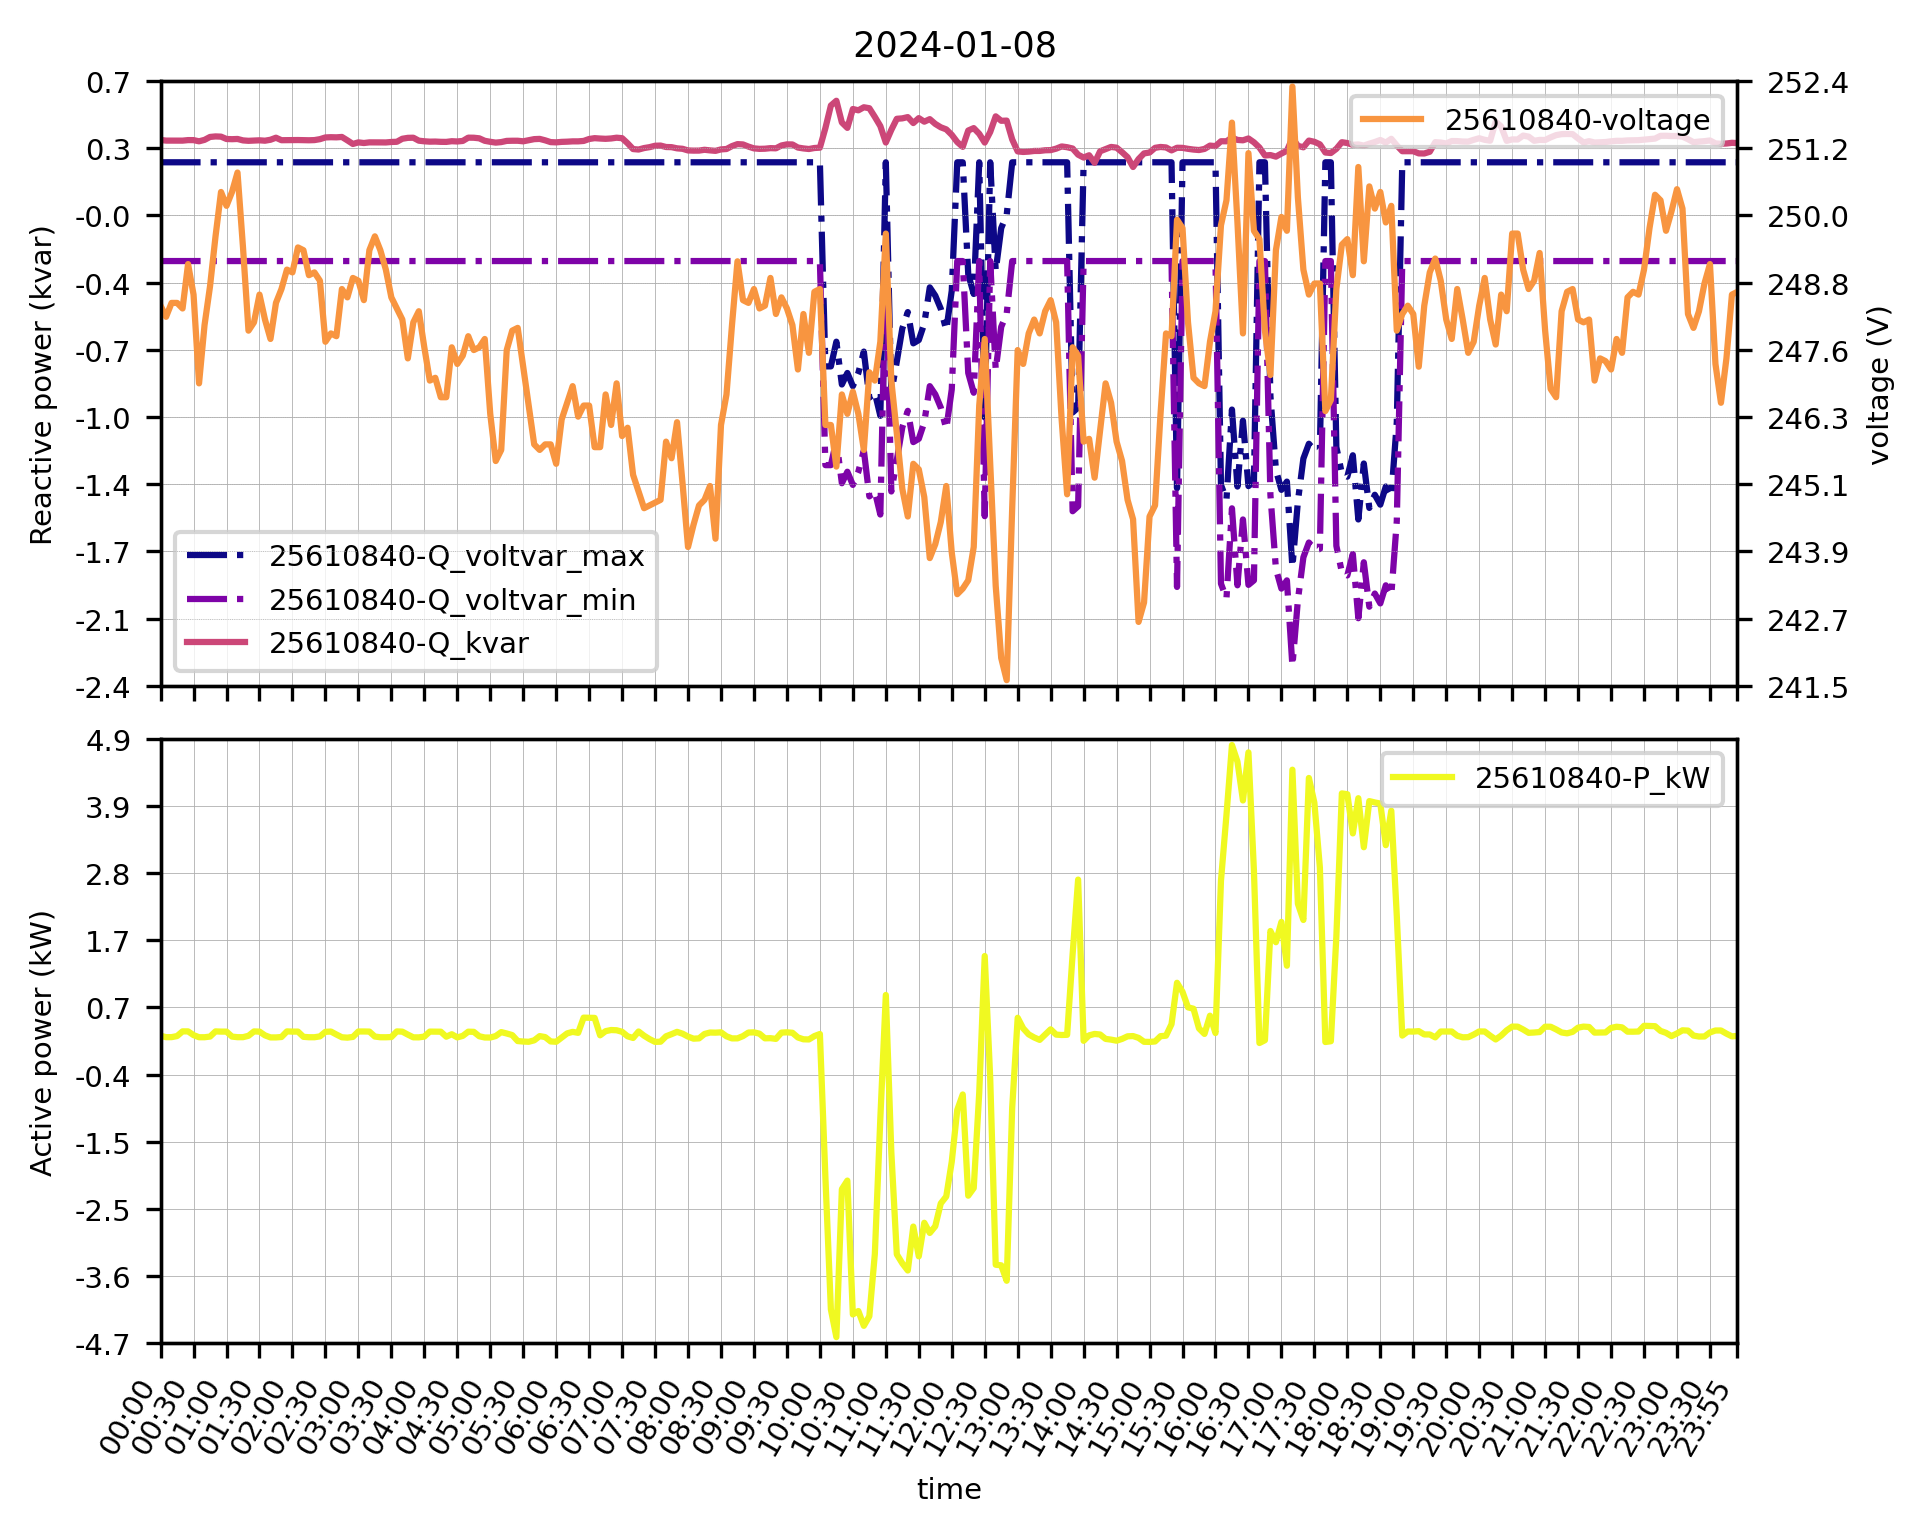

In [30]:
start_time = "2024-01-08 00:00:00+10:00"  # In sydney local time
end_time = "2024-01-09 00:00:00+10:00"  # In sydney local time


num_ticks = 24 * 2 + 1
save_as = ""
x_label = "time"
y_labels = [
    "Reactive power (kvar)",
    "Reactive power (kvar)",
    "Reactive power (kvar)",
    "voltage (V)",
    "Active power (kW)",
]
plt_config = {
    "Q_voltvar_max": [0, 0, "-.", None, None],
    "Q_voltvar_min": [0, 0, "-.", None, None],
    "Q_kvar": [0, 0, "-", None, None],
    "voltage": [0, 1, "-", None, None],
    "P_kW": [1, 0, "-", None, None],
}
# y_labels = ['Reactive power (kvar)', 'Reactive power (kvar)',  'voltage (V)', 'Active power (kW)']
# plt_config = {'Q_voltvar_max': [0, 0, '-.', None, None], 'Q_voltvar_min': [0, 0, '-.', None, None],
# 'voltage': [0, 1, '-', None, None], 'P_kW': [1, 0, '-', None, None]}

color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    dfp,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="site_id",
    time_attr="t_stamp",
    color_nights=color_nights,
    cmap="plasma",
    figsize=[16 / 2.54, 2.5],
    same_scale=1,
    fontsize=7,
    fontname="DejaVu Sans",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=300,
    x_format="%H:%M",
    legend_loc=["lower left", "upper right", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.2, 0.2],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=1,
    onlyntime=1,
)
a.do()

In [ ]:
df.filter(col("noncompliance_voltvar") > 0).select("circuit_id").show(
    40, truncate=False
)

+----------+-------------------+------------------+------------------+----------------------+--------------+--------------------+--------------------+-------------------+-------------------+-------------------+---------------------+
|circuit_id|t_stamp            |voltage           |P_kW              |Q_kvar                |ac_capacity_kw|Q_voltvar           |Q_voltvar_max       |Q_voltvar_min      |Q_capability_max   |Q_capability_min   |noncompliance_voltvar|
+----------+-------------------+------------------+------------------+----------------------+--------------+--------------------+--------------------+-------------------+-------------------+-------------------+---------------------+
|6066      |2024-01-01 00:00:00|246.14999999999998|0.6483233         |0.0055236             |3.0           |-0.6149999999999975 |1.4700000000000002  |1.17               |1.4700000000000002 |1.17               |1.1644763999999999   |
|6066      |2024-01-01 00:05:00|246.55            |0.8101233        

In [7]:
dfv = (
    spark.read.table("ts")
    .filter("is_pv = True ")
    .select("circuit_id", "t_stamp", "voltage")
    .filter("voltage < 0")
)
dfv.groupBy("circuit_id").agg(spark_count("voltage").alias("count_above_300")).sort(
    "count_above_300", ascending=False
).show(truncate=False)

+----------+---------------+
|circuit_id|count_above_300|
+----------+---------------+
|269023    |1              |
+----------+---------------+



In [5]:
df = (
    spark.read.table("ts")
    .filter("is_pv = True and year = 2024 and month=1")
    .select("circuit_id", "t_stamp")
)

# Define a window partitioned by circuit_id and ordered by timestamp
w = Window.partitionBy("circuit_id").orderBy("t_stamp")

# Compute difference with previous row in seconds
df_diff = df.withColumn("prev_t_stamp", lag("t_stamp").over(w)).withColumn(
    "diff_seconds", (col("t_stamp").cast("long") - col("prev_t_stamp").cast("long"))
)

# Show distinct differences per circuit
min_diff_per_circuit = df_diff.groupBy("circuit_id").agg(
    spark_min("diff_seconds").alias("min_diff_seconds")
)
min_diff_per_circuit.sort("min_diff_seconds", ascending=False).show(truncate=False)

+----------+----------------+
|circuit_id|min_diff_seconds|
+----------+----------------+
|5439      |300             |
|5701      |300             |
|10153     |300             |
|6274      |300             |
|10150     |300             |
|10295     |300             |
|10428     |300             |
|10928     |300             |
|5328      |300             |
|14500     |300             |
|14465     |300             |
|14984     |300             |
|10155     |300             |
|15161     |300             |
|14810     |300             |
|23588     |300             |
|6066      |300             |
|28888     |300             |
|14900     |300             |
|28990     |300             |
+----------+----------------+
only showing top 20 rows
